<a href="https://colab.research.google.com/github/anshuman4515/Capstone-project/blob/main/Missing_value_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('/content/gurgaon_properties_outlier_treated (1).csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,house,signature global park,sohna road,0.85,7589.0,1120.0,Built Up area: 1120 (104.05 sq.m.),3.0,2.0,2.0,1.0,NaN,Under Construction,NaN,1120.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,15.0,373.333333
1,flat,Conscient Heritage Max4.3 ★,sector 102,1.75,9063.0,1931.0,Super Built up area 1931(179.4 sq.m.),3.0,4.0,NaN,16.0,South,Relatively New,1931.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,134.0,643.666667
2,flat,Alpha Corp GurgaonOne 844.0 ★,sector 84,2.24,6523.0,3434.0,Super Built up area 3434(319.03 sq.m.)Carpet a...,4.0,4.0,3.0,12.0,West,Relatively New,3434.0,NaN,2900.0,0.0,1.0,0.0,0.0,0.0,0.0,20.0,858.500000
3,flat,Indiabulls Enigma,sector 110,3.40,10000.0,3400.0,Super Built up area 3400(315.87 sq.m.)Built Up...,4.0,5.0,3.0,10.0,South-West,Relatively New,3400.0,3000.0,2800.0,0.0,1.0,0.0,0.0,0.0,0.0,152.0,850.000000
4,flat,Tulip Violet4.3 ★,sector 69,1.75,8883.0,1970.0,Super Built up area 1970(183.02 sq.m.),4.0,4.0,1.0,12.0,North-West,Relatively New,1970.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,86.0,492.500000


In [5]:
df.shape

(3570, 24)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3570 entries, 0 to 3569
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3570 non-null   object 
 1   society              3569 non-null   object 
 2   sector               3570 non-null   object 
 3   price                3570 non-null   float64
 4   price_per_sqft       3570 non-null   float64
 5   area                 3570 non-null   float64
 6   areaWithType         3570 non-null   object 
 7   bedRoom              3570 non-null   float64
 8   bathroom             3570 non-null   float64
 9   balcony              2288 non-null   float64
 10  floorNum             3553 non-null   float64
 11  facing               2551 non-null   object 
 12  agePossession        3570 non-null   object 
 13  super_built_up_area  1872 non-null   float64
 14  built_up_area        1592 non-null   float64
 15  carpet_area          1852 non-null   f

In [7]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,1282


In [9]:
df['balcony'].value_counts()

,count
balcony,
3.0,1060
2.0,868
1.0,360


In [ ]:
df['balcony'].fillna(NA, inplace=True)

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

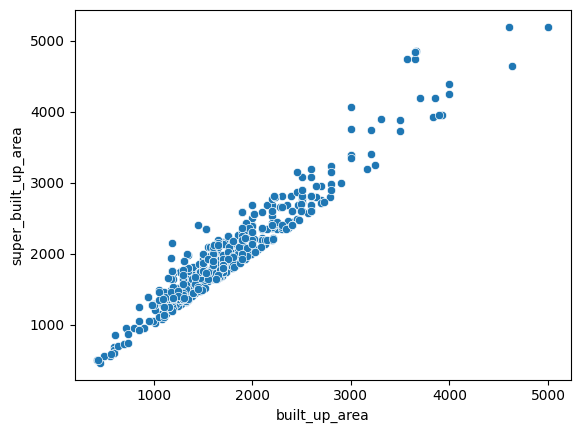

In [11]:
sns.scatterplot(x=df['built_up_area'], y=df['super_built_up_area'])


<Axes: xlabel='built_up_area', ylabel='carpet_area'>

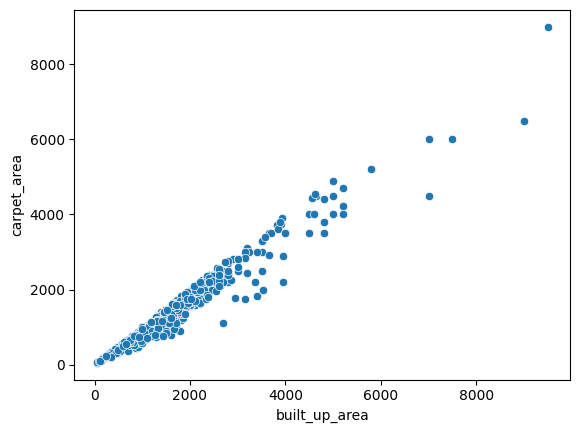

In [13]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [14]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

,0
0,False
1,False
2,False
3,False
4,False
...,...
3565,False
3566,False
3567,False
3568,False


In [16]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [17]:
all_present_df.shape

(530, 24)

In [18]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [19]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [20]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.1063815789473685 0.9


In [21]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [22]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
2,flat,Alpha Corp GurgaonOne 844.0 ★,sector 84,2.24,6523.0,3434.0,Super Built up area 3434(319.03 sq.m.)Carpet a...,4.0,4.0,3.0,12.0,West,Relatively New,3434.0,NaN,2900.0,0.0,1.0,0.0,0.0,0.0,0.0,20.0,858.500000
12,flat,Shree Vardhman Victoria3.8 ★,sector 70,1.64,8384.0,1956.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3.0,5.0,3.0,3.0,North,Relatively New,1950.0,NaN,1161.0,0.0,1.0,0.0,0.0,0.0,0.0,51.0,652.000000
19,flat,Ireo The Corridors,sector 67a,1.60,9265.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3.0,3.0,2.0,3.0,North,New Property,1727.0,NaN,1017.0,0.0,0.0,1.0,0.0,0.0,1.0,142.0,575.666667
23,flat,SS Almeria,sector 84,1.50,7500.0,2000.0,Super Built up area 2000(185.81 sq.m.)Carpet a...,3.0,3.0,3.0,2.0,NaN,New Property,2000.0,NaN,1700.0,0.0,1.0,0.0,0.0,0.0,0.0,108.0,666.666667
29,flat,Shapoorji Pallonji Joyville Gurugram4.0 ★,sector 102,1.20,14563.0,824.0,Super Built up area 1359(126.26 sq.m.)Carpet a...,2.0,2.0,3.0,0.0,North-East,Relatively New,1359.0,NaN,824.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,412.000000


In [23]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

/tmp/ipykernel_439/1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
/tmp/ipykernel_439/1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbc_df['built_up_area'].fillna(round(((sbc_df['super_buil

In [24]:
df.update(sbc_df)

In [25]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,1282


In [26]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [27]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,flat,Conscient Heritage Max4.3 ★,sector 102,1.75,9063.0,1931.0,Super Built up area 1931(179.4 sq.m.),3.0,4.0,NaN,16.0,South,Relatively New,1931.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,134.0,643.666667
4,flat,Tulip Violet4.3 ★,sector 69,1.75,8883.0,1970.0,Super Built up area 1970(183.02 sq.m.),4.0,4.0,1.0,12.0,North-West,Relatively New,1970.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,86.0,492.500000
5,flat,M3M Woodshire4.0 ★,sector 107,1.32,6331.0,2085.0,Super Built up area 1943(180.51 sq.m.),3.0,3.0,3.0,10.0,East,Relatively New,1943.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,117.0,695.000000
6,flat,Ansal API Celebrity Suites,sector 2,0.60,8163.0,735.0,Super Built up area 735(68.28 sq.m.),1.0,1.0,1.0,5.0,North-East,Moderately Old,735.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,67.0,735.000000
10,flat,Indiabulls Enigma,sector 110,3.70,10882.0,3400.0,Super Built up area 3400(315.87 sq.m.),4.0,5.0,3.0,7.0,South-West,Relatively New,3400.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,156.0,850.000000


In [28]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

/tmp/ipykernel_439/1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
/tmp/ipykernel_439/1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)


In [29]:
df.update(sb_df)

In [30]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,1282


In [31]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [32]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
11,flat,DLF Regency Park 13.6 ★,sector 28,1.60,14545.0,1100.0,Carpet area: 1100 (102.19 sq.m.),2.0,2.0,2.0,3.0,North,Relatively New,NaN,NaN,1100.0,0.0,0.0,0.0,0.0,0.0,0.0,52.0,550.000000
20,flat,M3M Golfestate4.4 ★,sector 65,7.00,18182.0,3850.0,Carpet area: 3850 (357.68 sq.m.),3.0,3.0,2.0,12.0,North,Moderately Old,NaN,NaN,3850.0,0.0,0.0,1.0,0.0,0.0,0.0,60.0,1283.333333
27,flat,Pyramid Urban Homes 2,sector 86,0.41,8283.0,495.0,Carpet area: 501 (46.54 sq.m.),2.0,2.0,1.0,7.0,West,New Property,NaN,NaN,501.0,1.0,1.0,0.0,1.0,1.0,0.0,49.0,247.500000
46,flat,Godrej Summit3.7 ★,sector 104,1.16,11208.0,1035.0,Carpet area: 1816 (168.71 sq.m.),3.0,4.0,NaN,8.0,East,Relatively New,NaN,NaN,1816.0,0.0,1.0,0.0,0.0,0.0,1.0,96.0,345.000000
52,flat,Viridian The Plaza 106,sector 106,0.46,6571.0,700.0,Carpet area: 700 (65.03 sq.m.),1.0,1.0,1.0,18.0,NaN,New Property,NaN,NaN,700.0,0.0,0.0,0.0,0.0,0.0,0.0,104.0,700.000000


In [33]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

/tmp/ipykernel_439/2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
/tmp/ipykernel_439/2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)


In [34]:
df.update(c_df)

In [35]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,1282


<Axes: xlabel='built_up_area', ylabel='price'>

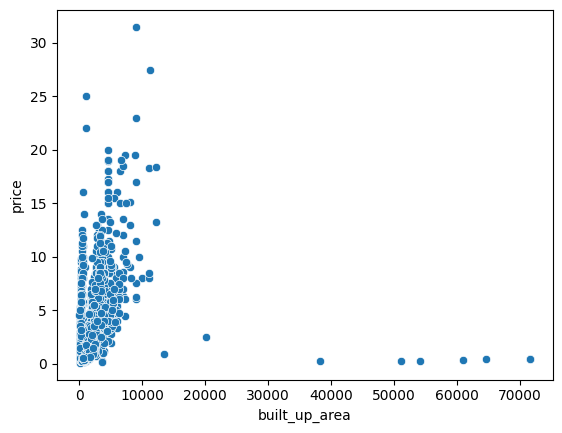

In [37]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [38]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [39]:
anamoly_df.sample(5)

,price,area,built_up_area
3438,5.25,1935.0,1935.0
1727,3.50,1080.0,1080.0
1701,5.50,1800.0,1800.0
1987,4.99,2642.0,270.0
443,2.58,2200.0,1991.0


In [40]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [41]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

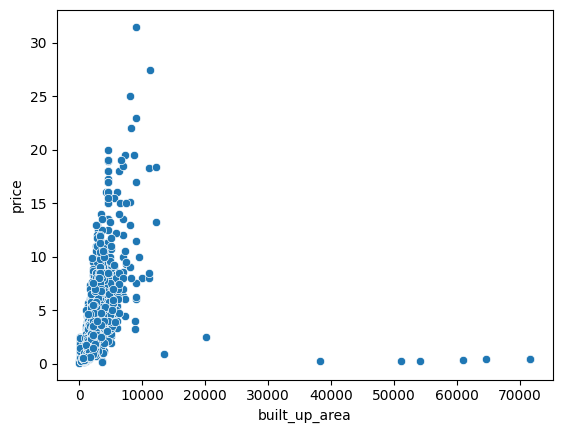

In [43]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [44]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [45]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,signature global park,sohna road,0.85,7589.0,3.0,2.0,2.0,1.0,NaN,Under Construction,1120.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
1,flat,Conscient Heritage Max4.3 ★,sector 102,1.75,9063.0,3.0,4.0,NaN,16.0,South,Relatively New,1748.0,0.0,1.0,0.0,0.0,0.0,1.0,134.0
2,flat,Alpha Corp GurgaonOne 844.0 ★,sector 84,2.24,6523.0,4.0,4.0,3.0,12.0,West,Relatively New,3165.0,0.0,1.0,0.0,0.0,0.0,0.0,20.0
3,flat,Indiabulls Enigma,sector 110,3.40,10000.0,4.0,5.0,3.0,10.0,South-West,Relatively New,3000.0,0.0,1.0,0.0,0.0,0.0,0.0,152.0
4,flat,Tulip Violet4.3 ★,sector 69,1.75,8883.0,4.0,4.0,1.0,12.0,North-West,Relatively New,1783.0,0.0,0.0,0.0,0.0,0.0,0.0,86.0


In [46]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,1282
floorNum,17
facing,1019


floorNUM

In [47]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
695,house,independent,sector 4,4.12,8889.0,2.0,1.0,NaN,NaN,NaN,Moderately Old,4635.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
776,house,jacob pura,sector 12,0.35,9722.0,2.0,1.0,NaN,NaN,NaN,Old Property,360.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
810,house,emaar mgf marbella,sector 66,9.00,21251.0,4.0,4.0,NaN,NaN,South-West,Relatively New,5200.0,0.0,1.0,1.0,1.0,0.0,1.0,114.0
904,flat,NaN,sector 78,0.60,3692.0,2.0,2.0,NaN,NaN,NaN,Under Construction,1625.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1165,flat,Experion Heartsong,dwarka expressway,1.08,6150.0,3.0,3.0,NaN,NaN,NaN,Under Construction,1758.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1271,house,independent,sector 26,4.60,12198.0,4.0,4.0,NaN,NaN,NaN,Old Property,3771.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0
1579,house,independent,sector 4,0.65,11111.0,4.0,2.0,2.0,NaN,NaN,Moderately Old,585.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1583,house,independent,sector 25,13.00,45710.0,6.0,8.0,NaN,NaN,NaN,Relatively New,2844.0,1.0,1.0,1.0,1.0,0.0,2.0,0.0
1698,house,dlf new town heights,sector 86,2.47,7719.0,4.0,4.0,NaN,NaN,West,Moderately Old,2800.0,0.0,1.0,0.0,1.0,0.0,1.0,130.0
2098,house,independent,sector 3,1.50,10288.0,3.0,3.0,NaN,NaN,NaN,Old Property,210.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [49]:
df['floorNum'].fillna(2.0,inplace=True)

/tmp/ipykernel_439/15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [50]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,1282
floorNum,0
facing,1019


In [51]:
1011/df.shape[0]

0.28319327731092436

facing

<Axes: ylabel='count'>

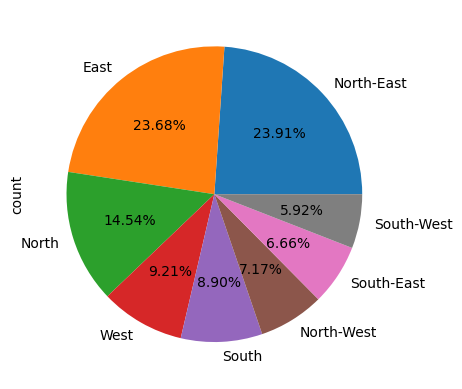

In [52]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [53]:
df.drop(columns=['facing'],inplace=True)

In [54]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1342,flat,ATS Tourmaline3.9 ★,sector 109,1.40,8000.0,3.0,3.0,NaN,5.0,Relatively New,1466.00,0.0,0.0,0.0,0.0,0.0,0.0,44.0
545,flat,Signature Global Solera3.7 ★,sector 107,0.28,5680.0,2.0,2.0,2.0,6.0,Relatively New,543.00,0.0,0.0,0.0,0.0,0.0,0.0,45.0
315,flat,Experion The Heartsong3.9 ★,sector 108,1.65,8238.0,3.0,4.0,3.0,3.0,Moderately Old,1771.32,1.0,0.0,0.0,0.0,0.0,1.0,75.0
2309,flat,Suncity Vatsal Valley,gwal pahari,1.28,9552.0,3.0,3.0,3.0,1.0,Relatively New,1489.00,0.0,0.0,0.0,0.0,0.0,1.0,49.0
3522,flat,Tulip Violet4.2 ★,sector 69,1.20,8889.0,2.0,3.0,1.0,0.0,Relatively New,1222.00,0.0,0.0,0.0,0.0,0.0,0.0,150.0


In [55]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,1282
floorNum,0
agePossession,0


In [56]:
df.drop(index=[2536],inplace=True)

In [57]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,1281
floorNum,0
agePossession,0


agePossession

In [58]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1611
New Property,558
Moderately Old,542
Undefined,298
Old Property,296
Under Construction,264


In [59]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
9,flat,Milan CGHS 9,sector 39,2.00,8333.0,3.0,3.0,NaN,0.0,Undefined,2400.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,flat,CHD Avenue 713.6 ★,sector 71,0.95,7917.0,2.0,2.0,NaN,5.0,Undefined,1200.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,flat,Satya The Hermitage3.5 ★,sector 103,0.80,5517.0,2.0,2.0,NaN,10.0,Undefined,1450.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22,flat,Sidhartha NCR One,sector 95,0.57,4179.0,2.0,2.0,2.0,10.0,Undefined,1364.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59,flat,Ramprasta AWHO,sector 95,0.92,5257.0,3.0,3.0,NaN,13.0,Undefined,1750.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486,flat,M3M Heights,sector 65,2.15,15003.0,2.0,2.0,NaN,28.0,Undefined,1433.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3493,house,independent,jyoti park,1.16,11717.0,5.0,4.0,2.0,1.0,Undefined,122.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3494,flat,Sapphire Eighty Three,sector 83,0.65,9286.0,1.0,1.0,NaN,6.0,Undefined,700.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3513,house,independent,sector 38,8.00,25616.0,10.0,10.0,NaN,1.0,Undefined,3123.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [60]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,1281
floorNum,0
agePossession,0


In [61]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [62]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [63]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1733
New Property,587
Moderately Old,582
Old Property,325
Under Construction,278
Undefined,64


In [64]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [66]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [67]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1745
New Property,588
Moderately Old,585
Old Property,325
Under Construction,278
Undefined,48


In [68]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [69]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [70]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1750
Moderately Old,628
New Property,588
Old Property,325
Under Construction,278


In [71]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,1281
floorNum,0
agePossession,0


In [74]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
904,flat,NaN,sector 78,0.6,3692.0,2.0,2.0,NaN,2.0,Under Construction,1625.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
import numpy as np

df['balcony'].fillna(0, inplace=True)


/tmp/ipykernel_439/3460353471.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['balcony'].fillna(0, inplace=True)


In [78]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [79]:
r=df[df['society'].isnull()]

In [80]:
r

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
904,flat,NaN,sector 78,0.6,3692.0,2.0,2.0,0.0,2.0,Under Construction,1625.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [82]:

df.drop(r.index, inplace=True)


In [83]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [84]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [85]:
df.shape

(3568, 18)